# Import and Data filtering

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

data.head()

,Unnamed: 0,time_stamp,isin,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,0,2015-01-07 17:44:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
1,1,2015-01-07 17:43:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
2,2,2015-01-07 17:42:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
3,3,2015-01-07 17:41:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961
4,4,2015-01-07 17:40:00+00:00,DE0001102366,104.835,0.4835,DE,10,ref,9.601643,0.000961


# Estimation des return

In [4]:
# on def ret_t = Pt-Pt-1/Pt-1 + Yieldt−1​×Δt​/T
# on suppose Δt​/T = 1/252  


data = data.sort_values(['isin', 'time_stamp'])
#data['delta_yield'] = data.groupby('isin')['yield'].diff()
data['price_return'] = data.groupby('isin')['price'].apply(lambda x: x.pct_change())
data['total_return'] = data['price_return'] + data['yield'].shift(1)*(1/252)  # daily approx


C:\Users\hugoj\AppData\Local\Temp\ipykernel_15464\2216037918.py:7: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  data['price_return'] = data.groupby('isin')['price'].apply(lambda x: x.pct_change())


In [5]:
df_FR = data[data["country_iso"]=="FR"]
df_DE = data[data["country_iso"]=="DE"]
df_IT = data[data["country_iso"]=="IT"]

val = "total_return"
df_FR = df_FR.pivot(index="time_stamp", values=val, columns="mat_cat")
df_DE = df_DE.pivot(index="time_stamp", values=val, columns="mat_cat")
df_IT = df_IT.pivot(index="time_stamp", values=val, columns="mat_cat")

df_FR.index = pd.to_datetime(df_FR.index)
df_DE.index = pd.to_datetime(df_DE.index)
df_IT.index = pd.to_datetime(df_IT.index)


In [6]:
df_FR.head()

mat_cat,2,5,10,15,30
time_stamp,,,,,
2015-01-01 06:45:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-01 06:46:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-01 06:47:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-01 06:48:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-01 06:49:00+00:00,NaN,NaN,NaN,0.005538,NaN


In [7]:
df_FR = df_FR.resample('1D').last()
df_DE = df_DE.resample('1D').last()
df_IT = df_IT.resample('1D').last()

df_FR

mat_cat,2,5,10,15,30
time_stamp,,,,,
2015-01-01 00:00:00+00:00,NaN,NaN,NaN,0.005538,NaN
2015-01-02 00:00:00+00:00,NaN,NaN,NaN,0.005540,NaN
2015-01-03 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-04 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-05 00:00:00+00:00,NaN,NaN,NaN,0.005377,NaN
...,...,...,...,...,...
2025-10-17 00:00:00+00:00,0.008445,0.010565,0.013365,0.014954,0.016725
2025-10-18 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2025-10-19 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN


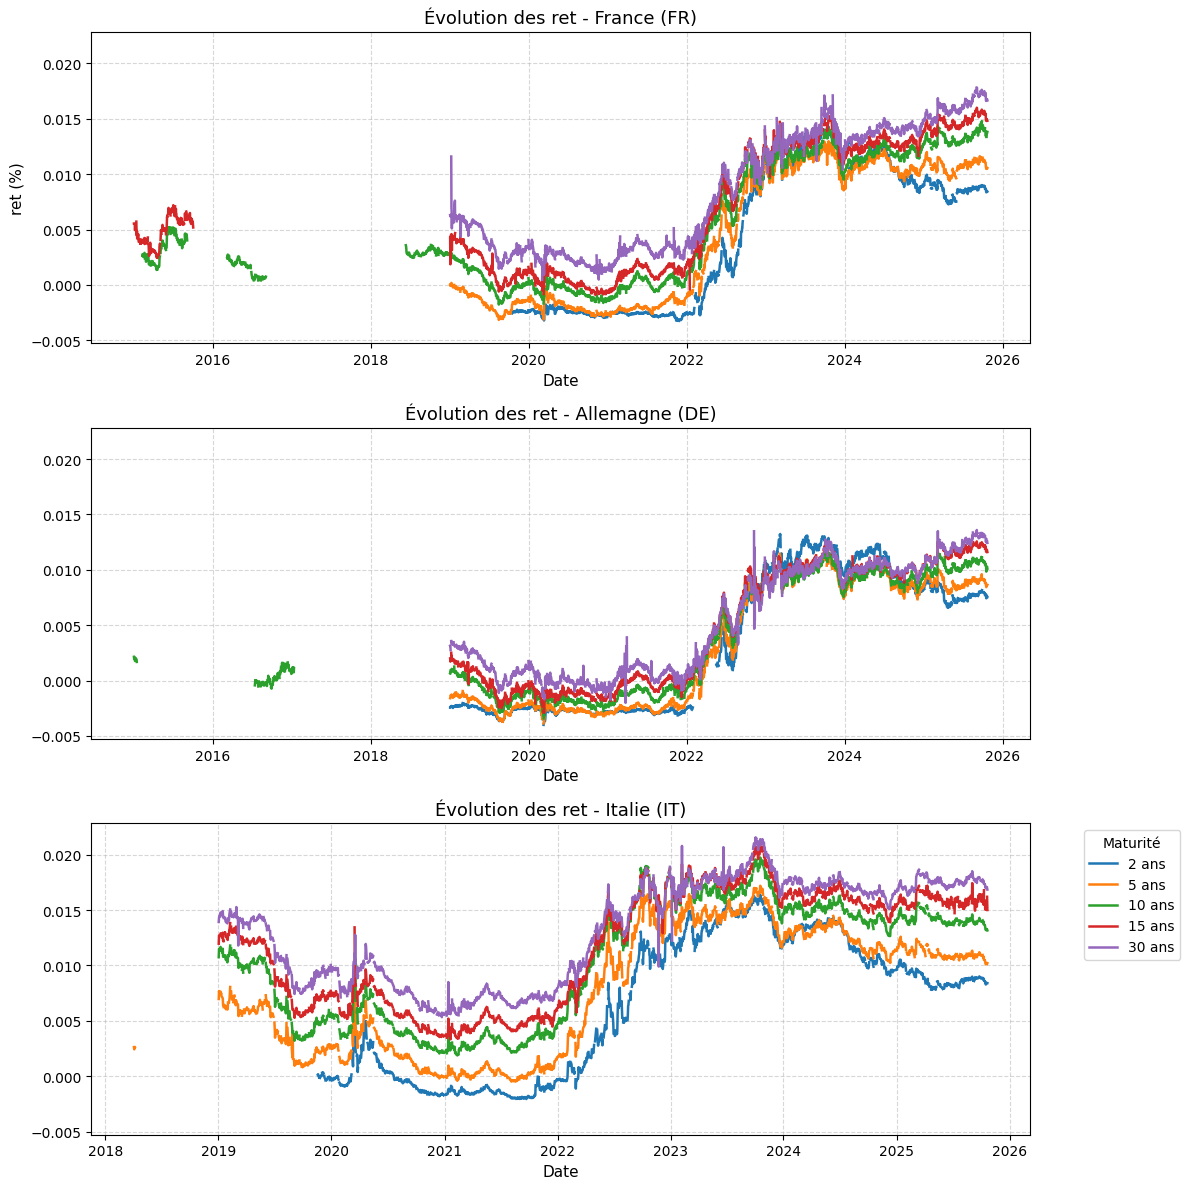

In [9]:
import matplotlib.pyplot as plt

# Figure globale : 3 sous-graphiques côte à côte
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=True)

# Dictionnaire pour simplifier la boucle
dfs = {
    "France (FR)": df_FR,
    "Allemagne (DE)": df_DE,
    "Italie (IT)": df_IT
}

# Boucle sur les pays
for ax, (country, df) in zip(axes, dfs.items()):
    # Tracé
    for col in df.columns:
        ax.plot(df.index, df[col], label=f"{col} ans", linewidth=1.8)
    
    # Titres et labels
    ax.set_title(f"Évolution des ret - {country}", fontsize=13)
    ax.set_xlabel("Date", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    
# Label vertical partagé
axes[0].set_ylabel("ret (%)", fontsize=11)

# Légende commune
axes[-1].legend(title="Maturité", bbox_to_anchor=(1.05, 1), loc='upper left')

# Mise en page
plt.tight_layout()
plt.show()


# Creation d'UN portfolio

In [116]:

class Portfolio():
    def __init__(self, data_dict,date, benchmark = "ew", long_only = False, lamb = 1):
        """
        data_dict : dict
            Dictionnaire de DataFrames (par ex. {'FR': df_FR, 'DE': df_DE, 'IT': df_IT})
            Chaque DataFrame a un DatetimeIndex et des colonnes = maturités (mat_cat)
        
        date : datetime
            On précise la date du portfeuille 

        benchmark : string
            On précise ce qu'est notre benchmark si contrainte de distance au bm
            Pas utilisé pour le moment
            ew = equally weigted
        """

        self.data = data_dict
        self.date = date
        self.benchmark = benchmark
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.long_only = long_only
        self.lamb = lamb
        self.benchmark_weights = None


    def get_returns_until(self):
        """
        Calcule les rendements journaliers jusqu’à la date donnée (incluse !!) 
        à modifier pour traiter plutôt avec les DV01
        """

        date_t = pd.to_datetime(self.date)
        all_returns = []

        for country, df in self.data.items():
            # Garder uniquement les observations avant t compris
            df_t = df[df.index <= date_t]
            
            # Calcul du rendement journalier à modif 
            rets = df_t.dropna()
            rets.columns = [f"{country}_{c}" for c in rets.columns]
            all_returns.append(rets)

        # Fusionner toutes les séries
        self.returns = pd.concat(all_returns, axis=1).dropna()
        
    
    def estimate_returns(self):
        """
        Estime le vecteur returns, avec moyenne pour le moment
        """

        self.mean_returns = self.returns.mean()
        
    
    def estimate_cov_matrix(self):
        """
        Estime la matrice de covariance, simple pour le moment
        """
        self.cov_matrix = self.cov_matrix = self.returns.cov()
        
    

    def simple_marokwitz(self, normalize = False):
        """
        Markowitz simple, sans contrainte longue and short V = wTR - lambda*wTsigmaw 
        a faire plus tard : rajouter contraintes, faire optimisation à partir de seuil 
        de return ou variance

        Le long_only est à modifier, il faut faire une optimization sur w >= 0 
        """
        mu = np.array(self.mean_returns)
        Sigma = np.array(self.cov_matrix) + 0.001*np.diag(np.ones(self.cov_matrix.shape[0]))
        
        # Poids non normalisés
        w = np.linalg.inv(2 * self.lamb * Sigma) @ mu

        if self.long_only:
            w = np.maximum(w, 0)   # coupe les négatifs
            w /= w.sum()           # on normalize toujours les long_only 
        
        if normalize:
            w /= w.sum()
            
        self.weights = pd.DataFrame(w, index=self.mean_returns.index, columns=[self.date])
    
    def benchmark_w(self):
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(self.mean_returns.shape)/self.mean_returns.shape, index=self.mean_returns.index, columns=[self.date])
        

    def process(self):
        """
        Process entier pour obtenier les poids finaux
        """
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix()
        self.simple_marokwitz()
        self.benchmark_w()
        return self.weights

data_dict = {
    'FR': df_FR,
    'DE': df_DE,
    'IT': df_IT
}
date = "2020-01-01 00:00:00+00:00"
pf = Portfolio(data_dict,date)
w = pf.process()
print(w)

       2020-01-01 00:00:00+00:00
FR_2                   -1.205687
FR_5                   -0.726352
FR_10                   0.004892
FR_15                   0.535023
FR_30                   1.580535
DE_2                   -1.263382
DE_5                   -1.100689
DE_10                  -0.597917
DE_15                  -0.329499
DE_30                   0.461420
IT_2                   -0.028116
IT_5                    1.196501
IT_10                   2.555864
IT_15                   3.603262
IT_30                   4.715126


# Creation du time serie pf

In [117]:
class TimeSeriesPortfolio():
    def __init__(self, data_dict, start_date, end_date, rebalance_freq='1D', long_only=False, lamb=1,benchamark = "ew"):
        """
        data_dict : dict
            Dictionnaire de DataFrames par pays {'FR': df_FR, ...}
            Chaque DataFrame a un DatetimeIndex et des colonnes = maturités (mat_cat)
        start_date, end_date : str/datetime
            Dates de début et fin du backtest
        rebalance_freq : str
            Pandas offset alias ('1D', '1W', '1M', ...)
            On a fait une approxi ici, à modif dans le futur
        long_only : bool
            Long only ou pas
        lamb : float
            Coefficient de risque pour Markowitz
        """
        self.data_dict = data_dict
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = lamb
        self.benchmark = benchamark
        self.dates = None
        self.weights_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}


    def generate_rebalance_dates(self):
        """
        On filtre les dates pour construire self.dates
        """
        # union de tous les index
        all_dates = None
        for df in self.data_dict.values():
            if all_dates is None:
                all_dates = df.index
            else:
                all_dates = all_dates.union(df.index)

        #all_dates = pd.concat([df.index for df in list(self.data_dict.values())]).sort_values().drop_duplicates()
        # filtre la période

        all_dates = all_dates[(all_dates >= self.start_date) & (all_dates <= self.end_date)]
        # échantillonne selon rebalance_freq

        rebalance_dates = all_dates[::self.freq_to_step(all_dates)]
        self.dates = rebalance_dates
        return self.dates

    def freq_to_step(self, all_dates):
        """
        Convert pandas offset alias en step integer pour slicing
        """
        
        if self.rebalance_freq.endswith('D'):
            print("D")
            return int(self.rebalance_freq[:-1])
        elif self.rebalance_freq.endswith('W'):
            print("W")
            return int(self.rebalance_freq[:-1]) * 5  # approx semaine = 5 jours de trading
        elif self.rebalance_freq.endswith('M'):
            print("M")
            return int(self.rebalance_freq[:-1]) * 21  # approx mois = 21 jours
        else:
            print("1")
            return 1
        

    # Générer les portefeuilles jour par jour
    def generate_portfolios(self):
        if self.dates is None:
            self.generate_rebalance_dates()

        pf_weights = []
        bm_weights = []
        pf_returns = []
        bm_returns = []

        for t in self.dates:
            # --- Créer portefeuille pour la date t ---
            pf = Portfolio(self.data_dict, t, long_only=self.long_only, lamb = self.lamb)
            w = pf.process()
            pf_weights.append(w.values.flatten())
            bm_weights.append(pf.benchmark_weights.values.flatten())

            # --- Calcul du rendement du portefeuille sur le jour suivant r_{t+1} ---
            # concaténer tous les returns
            all_returns = []
            for country, df in self.data_dict.items():
                df_next = df.loc[df.index[df.index > t]].head(1)
                
                if not df_next.empty:
                    df_next.columns = [f"{country}_{c}" for c in df_next.columns]
                    all_returns.append(df_next)
            #print(all_returns)
            if all_returns:
                r_next = pd.concat(all_returns, axis=1)
                #print(r_next.values.flatten())
                #print(w)
                #print(pf.benchmark_weights)
                pf_ret = np.dot(r_next.values.flatten(), w.values)[0]
                bm_ret = np.dot(r_next.values.flatten(), pf.benchmark_weights)[0]

                pf_returns.append(pf_ret)
                bm_returns.append(bm_ret)
            else:
                pf_returns.append(np.nan)
                bm_returns.append(np.nan)


        # Stockage historique
        self.weights_history = pd.DataFrame(pf_weights, index=self.dates)
        self.portfolio_returns = pd.Series(pf_returns, index=self.dates)
        self.benchmark_returns = pd.Series(bm_returns, index=self.dates)

        # differente Metrics 
        self.metrics = {
            'pf_cumulative_return': (1 + self.portfolio_returns).cumprod(),
            'bm_cumulative_return': (1 + self.benchmark_returns).cumprod(),
            'mean_return': self.portfolio_returns.mean(),
            'volatility': self.portfolio_returns.std(),
            'sharpe': self.portfolio_returns.mean() / self.portfolio_returns.std() if self.portfolio_returns.std() != 0 else np.nan
        }

        return self.weights_history, self.portfolio_returns


    # Plot weights ou performances

    def plot_weights(self):
        if self.weights_history.empty:
            raise ValueError("Aucune donnée de portefeuille. Lancez generate_portfolios()")
        self.weights_history.plot(figsize=(12,6))
        plt.title("Historique des poids du portefeuille")
        plt.xlabel("Date")
        plt.ylabel("Poids")
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()

    def plot_cumulative_return(self):
        if not self.metrics:
            raise ValueError("Aucune métrique calculée. Lancez generate_portfolios()")
        plt.figure(figsize=(12,6))
        self.metrics['pf_cumulative_return'].plot(label='Portfolio', color='blue')
        self.metrics['bm_cumulative_return'].plot(label='Benchmark', color='orange')
        
        plt.title("Performance cumulative : Portfolio vs Benchmark")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend(loc='best')
        plt.grid(True)
        plt.show()

In [120]:
data_dict = {
    'FR': df_FR,
    'DE': df_DE,
    'IT': df_IT
}

for country, df in data_dict.items():
    data_dict[country] = df.dropna(how='all')
start_date = "2020-01-01 00:00:00+00:00"
end_date = "2025-06-10 00:00:00+00:00"

tspf = TimeSeriesPortfolio(data_dict, start_date, end_date, rebalance_freq='1M', long_only=False)
_, _ = tspf.generate_portfolios()


M


In [104]:
tspf.metrics

{'pf_cumulative_return': time_stamp
 2020-01-02 00:00:00+00:00    1.003569
 2020-01-09 00:00:00+00:00    1.007913
 2020-01-16 00:00:00+00:00    1.011708
 2020-01-23 00:00:00+00:00    1.014955
 2020-01-30 00:00:00+00:00    1.015801
                                ...   
 2025-05-07 00:00:00+00:00    9.378442
 2025-05-14 00:00:00+00:00    9.493577
 2025-05-21 00:00:00+00:00    9.610785
 2025-05-28 00:00:00+00:00    9.724544
 2025-06-04 00:00:00+00:00    9.842091
 Length: 281, dtype: float64,
 'bm_cumulative_return': time_stamp
 2020-01-02 00:00:00+00:00    1.001267
 2020-01-09 00:00:00+00:00    1.002752
 2020-01-16 00:00:00+00:00    1.004251
 2020-01-23 00:00:00+00:00    1.005310
 2020-01-30 00:00:00+00:00    1.005511
                                ...   
 2025-05-07 00:00:00+00:00    6.339611
 2025-05-14 00:00:00+00:00    6.415563
 2025-05-21 00:00:00+00:00    6.492933
 2025-05-28 00:00:00+00:00    6.567833
 2025-06-04 00:00:00+00:00    6.646015
 Length: 281, dtype: float64,
 'mean_ret

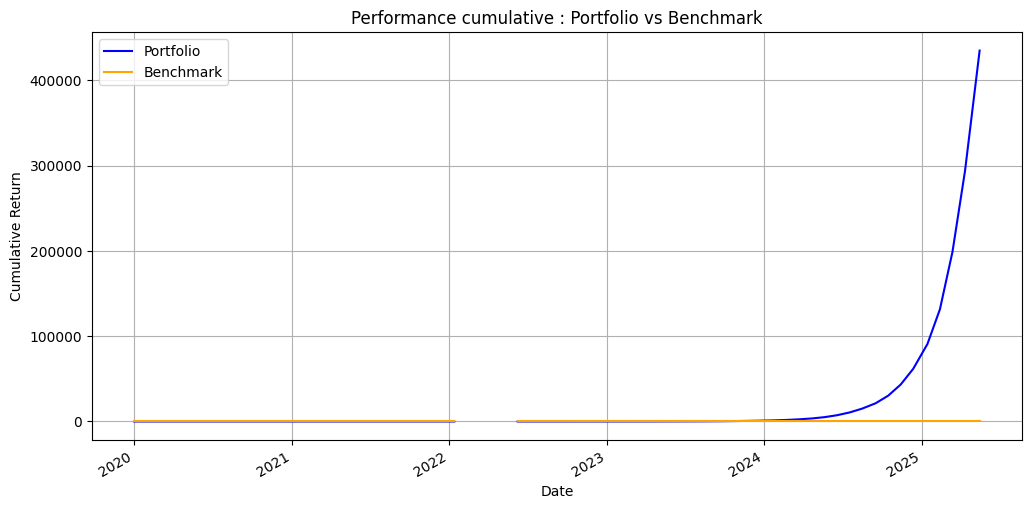

In [121]:
tspf.plot_cumulative_return()